In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv(dotenv_path='../.env')  # adjust path if your notebook isn't in a subfolder

db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

engine = create_engine(f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}?sslmode=require&channel_binding=require')

In [2]:
check = pd.read_sql('SELECT * FROM ratings ORDER BY "userId" DESC LIMIT 5', engine)
print(check)

   userId  movieId  rating   timestamp
0     610       16     4.5  1479542171
1     610       32     4.5  1479543331
2     610        1     5.0  1479542900
3     610        6     5.0  1493850345
4     610       47     5.0  1479545853


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
from surprise import SVD

In [2]:
ratings = pd.read_csv('../data/raw/ml-latest-small/ratings.csv')
movies = pd.read_csv('../data/raw/ml-latest-small/movies.csv')

print(ratings.shape)  # .shape returns the dimensions of a DataFrame as a tuple: (number_of_rows, number_of_columns)
print(movies.shape)

ratings.info()  # .info tells you data types and whether there are any missing values
movies.info()

(100836, 4)
(9742, 3)
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 228.5 KB


In [3]:
ratings.head()  # .head() shows you the first i (default = 5) rows of a DataFrame.
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings['rating'].value_counts().sort_index()  #.value_counts is like a Counter

rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

<Axes: title={'center': 'Rating Distribution'}, ylabel='Frequency'>

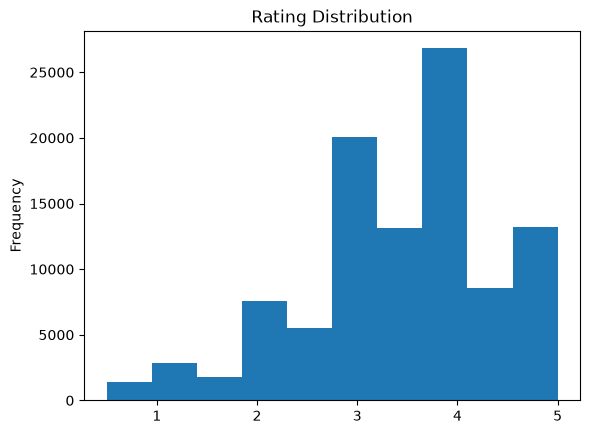

In [5]:
ratings['rating'].plot(kind='hist', bins=10, title='Rating Distribution')  # Plot the frequencies of ratings

In [6]:
print("Duplicate ratings:", ratings.duplicated().sum())  # Find the number of duplicated data
print("Missing values in ratings:\n", ratings.isnull().sum())  # Find the number of missing values in ratings
print("Missing values in movies:\n", movies.isnull().sum())

Duplicate ratings: 0
Missing values in ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
Missing values in movies:
 movieId    0
title      0
genres     0
dtype: int64


In [7]:
n_users = ratings['userId'].nunique()  # Number of unique users
n_movies = ratings['movieId'].nunique()  # Number of unique movies
n_ratings = len(ratings)

sparsity = 1 - (n_ratings / (n_users * n_movies))  # How much of a dataset is missing rather than filled in

print(f"Users: {n_users}, Movies: {n_movies}, Ratings: {n_ratings}")
print(f"Sparsity: {sparsity:.4f}")

Users: 610, Movies: 9724, Ratings: 100836
Sparsity: 0.9830


In [8]:
ratings_per_user = ratings.groupby('userId').size()
ratings_per_movie = ratings.groupby('movieId').size()

print(f"Ratings per user description: \n{ratings_per_user.describe()}\n")
print(f"Ratings per movie description: \n{ratings_per_movie.describe()}\n")

Ratings per user description: 
count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64

Ratings per movie description: 
count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64



In [9]:
data = ratings.merge(movies, on='movieId')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [10]:
# Retrieve movie ratings and add info columns
movie_stats = ratings.groupby('movieId').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count'),
    rating_sum=('rating', 'sum')
)

# Add a fake 5-star and a fake 0-star rating to every movie
movie_stats['adjusted_rating'] = (movie_stats['rating_sum'] + 5 + 0) / (movie_stats['rating_count'] + 2)

# Sort by the adjusted rating
popular_movies = movie_stats.sort_values('adjusted_rating', ascending=False)

# Merge in titles, but display the ORIGINAL stats alongside the adjusted score
popular_movies = popular_movies.merge(movies, on='movieId')
popular_movies[['title', 'adjusted_rating', 'avg_rating', 'rating_count']].head(10)

,title,adjusted_rating,avg_rating,rating_count
0,"Shawshank Redemption, The (1994)",4.416928,4.429022,317
1,"Three Billboards Outside Ebbing, Missouri (2017)",4.300000,4.750000,8
2,"Streetcar Named Desire, A (1951)",4.295455,4.475000,20
3,"Godfather, The (1972)",4.270619,4.289062,192
4,Secrets & Lies (1996),4.269231,4.590909,11
5,Fight Club (1999),4.256818,4.272936,218
6,Paths of Glory (1957),4.250000,4.541667,12
7,"Godfather: Part II, The (1974)",4.232824,4.259690,129
8,Dr. Strangelove or: How I Learned to Stop Worr...,4.232323,4.268041,97
9,Guess Who's Coming to Dinner (1967),4.230769,4.545455,11


In [18]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Surprise needs data in a specific format: userId, movieId, rating
reader = Reader(rating_scale=(0.5, 5.0))  # Telling Reader what is the range of ratings
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)  # Transform the data in what surprise needs

# Split into train/test
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)  # Let 80% for training, 20% for testing

# Train an SVD model
model = SVD(random_state=42)  # Model created ready to train
model.fit(trainset)  # Actual training

# Quick check: predict rating for a specific user/movie pair
prediction = model.predict(uid=1, iid=50)
print(prediction)

user: 1          item: 50         r_ui = None   est = 5.00   {'was_impossible': False}


In [19]:
ratings[(ratings['userId'] == 1) & (ratings['movieId'] == 50)]

,userId,movieId,rating,timestamp
4,1,50,5.0,964982931


In [20]:
def get_top_n_recommendations(user_id, model, movies_df, ratings_df, n=10):
    rated_movies = ratings_df[ratings_df['userId'] == user_id]['movieId'].tolist()  # Getting movies the user has alread rated
    all_movies = movies_df['movieId'].tolist()  # Grab all movies in the dataset
    unrated_movies = [m for m in all_movies if m not in rated_movies]  # Now getting movies the user have not rated

    predictions = [(movie_id, model.predict(user_id, movie_id).est) for movie_id in unrated_movies]  # Asks the model for each movie not rated an estimate rating the user would give

    predictions.sort(key=lambda x: x[1], reverse=True)  # Sort predictions
    top_n = predictions[:n]  # Get top n predictions

    # Convert the data into a proper Dataframe
    top_n_df = pd.DataFrame(top_n, columns=['movieId', 'predicted_rating'])
    top_n_df = top_n_df.merge(movies_df, on='movieId')

    # Add actual movie stats to the DataFrame to compare
    movie_stats = ratings_df.groupby('movieId').agg(
        actual_avg_rating=('rating', 'mean'),
        actual_rating_count=('rating', 'count')
    )
    top_n_df = top_n_df.merge(movie_stats, on='movieId')

    return top_n_df[['title', 'predicted_rating', 'actual_avg_rating', 'actual_rating_count']]
get_top_n_recommendations(user_id=1, model=model, movies_df=movies, ratings_df=ratings)

,title,predicted_rating,actual_avg_rating,actual_rating_count
0,Blade Runner (1982),5.0,4.100806,124
1,Ghost in the Shell (Kôkaku kidôtai) (1995),5.0,4.148148,27
2,Dr. Strangelove or: How I Learned to Stop Worr...,5.0,4.268041,97
3,North by Northwest (1959),5.0,4.184211,57
4,Casablanca (1942),5.0,4.240000,100
5,"Streetcar Named Desire, A (1951)",5.0,4.475000,20
6,Cinema Paradiso (Nuovo cinema Paradiso) (1989),5.0,4.161765,34
7,One Flew Over the Cuckoo's Nest (1975),5.0,4.203008,133
8,Lawrence of Arabia (1962),5.0,4.300000,45
9,"Grand Day Out with Wallace and Gromit, A (1989)",5.0,4.089286,28


In [40]:
# Generate predictions for every pair in the held-out test set
predictions = model.test(testset)

# Calculate RMSE (Root Mean Squared Error)
rmse = accuracy.rmse(predictions)

# Calculate MAE (Mean Absolute Error) 
mae = accuracy.mae(predictions)

RMSE: 0.8807
MAE:  0.6766


In [41]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=10, threshold=3.5):
    # Predict the rating that every user would rate to each movie
    user_est_true = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    # Set up dictionaries to store each user's precision and recall score
    precisions = {}
    recalls = {}

    # Iterating trough each user's estimated and actual ratings
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)  # Number of relevant reviews (+3.5)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])  # From the top k, how many of them were predicted as good (+3.5)
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )  # From the top k, how many of them were good (+3.5), and are actually good
        
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0  # Of the things I recommended, how many were actually good
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0  # Of all the good movies that existed for this user, how many did I catch in my top 10
    return precisions, recalls

precisions, recalls = precision_recall_at_k(predictions, k=10, threshold=3.5)

# Average precision and recall
avg_precision = sum(prec for prec in precisions.values()) / len(precisions)
avg_recall = sum(rec for rec in recalls.values()) / len(recalls)

print(f"Precision@10: {avg_precision:.3f}")
print(f"Recall@10: {avg_recall:.3f}")

Precision@10: 0.745
Recall@10: 0.509


In [48]:
from surprise import NormalPredictor

# Trainng a baseline model predicting randomly based on the total average rating and sparsity
baseline_model = NormalPredictor()
baseline_model.fit(trainset)
baseline_predictions = baseline_model.test(testset)

# Printing the comparison between our model and the baseline
print("--- SVD ---")
accuracy.rmse(predictions)
accuracy.mae(predictions)
print()

print("--- Baseline ---")
print("Baseline ", end="")
accuracy.rmse(baseline_predictions)
print("Baseline ", end="")
_ = accuracy.mae(baseline_predictions)

--- SVD ---
RMSE: 0.8807
MAE:  0.6766

--- Baseline ---
Baseline RMSE: 1.4296
Baseline MAE:  1.1407


In [49]:
# Creating a new folder for saving the models
import os
os.makedirs('../models', exist_ok=True)

In [50]:
import pickle
with open('../models/svd_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


In [51]:
# Verifying the model was saved in the correct file
print(os.path.exists('../models/svd_model.pkl'))
print(os.path.getsize('../models/svd_model.pkl'), "bytes")

True
10020232 bytes


In [52]:
with open('../models/svd_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test it makes the same prediction as before
print(loaded_model.predict(uid=1, iid=50))

user: 1          item: 50         r_ui = None   est = 5.00   {'was_impossible': False}
